In [3]:
import pandas as pd
import numpy as np

bike_df = pd.read_csv('./data/bike_train.csv')
bike_test = pd.read_csv('./data/bike_test.csv')

bike_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
bike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [5]:
# 결측치 확인
bike_df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [6]:
copy_df = bike_df.copy()
copy_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [7]:
copy_df['datetime'] = pd.to_datetime(copy_df['datetime'])
copy_df['year'] = copy_df.datetime.apply(lambda x: x.year)
copy_df['month'] = copy_df.datetime.apply(lambda x: x.month)
copy_df['day'] = copy_df.datetime.apply(lambda x: x.day)
copy_df['hour'] = copy_df.datetime.apply(lambda x: x.hour)

copy_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4


In [8]:
copy_df = copy_df.drop('datetime', axis = 1)
copy_df = copy_df.drop('casual', axis = 1)
copy_df = copy_df.drop('registered', axis = 1)


In [9]:
X_data = copy_df.drop(['count'], axis=1)
y_target = copy_df['count']

In [10]:
y_target_log = np.log1p(y_target)

In [11]:
from sklearn.model_selection import cross_val_score

def get_model_cv_prediction(model,
                            X_data,
                            y_target):

    neg_mse_scores = cross_val_score(
        model,
        X_data,
        y_target,
        scoring = 'neg_mean_squared_error',
        cv = 5
    )

    rmse_scores = np.sqrt(-1 * neg_mse_scores)

    avg_rmse = np.mean(rmse_scores)

    print(model.__class__.__name__)
    print(avg_rmse)

    return avg_rmse

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


lr_reg = LinearRegression()

dt_reg = DecisionTreeRegressor(random_state = 42,
                               max_depth = 4)

rf_reg = RandomForestRegressor(random_state = 42,
                               n_estimators = 1000,
                               n_jobs = -1)

gb_reg = GradientBoostingRegressor(random_state = 42,
                                   n_estimators = 1000)

xgb_reg = XGBRegressor(n_estimators = 1000)

lgb_reg = LGBMRegressor(n_estimators = 1000)

models = [lr_reg, dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]

for model in models:
    get_model_cv_prediction(model,
                            X_data,
                            y_target_log)

LinearRegression
1.024645509242554
DecisionTreeRegressor
0.7890434231255824
RandomForestRegressor
0.46746590833887025
GradientBoostingRegressor
0.4163465457616361
XGBRegressor
0.44417736087346044
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 12
[LightGBM] [Info] Start training from score 4.753723
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points in the train set: 8709, number of used features: 12
[LightGBM] [Info] Start training from score 4.568

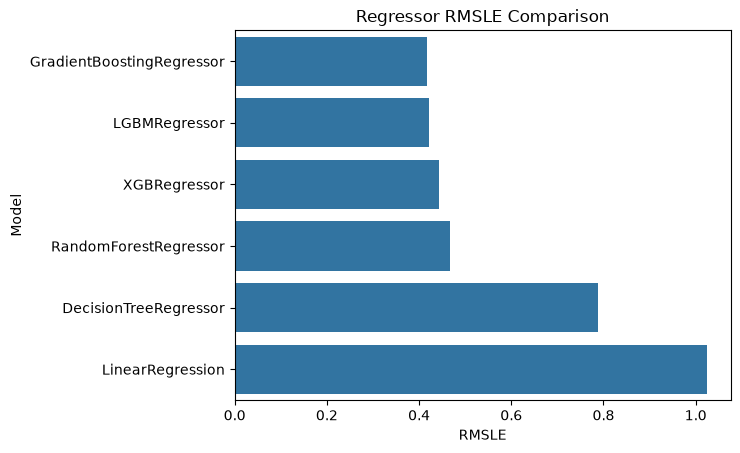

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

model_names = [
    'LinearRegression',
    'DecisionTreeRegressor',
    'RandomForestRegressor',
    'GradientBoostingRegressor',
    'XGBRegressor',
    'LGBMRegressor'
]

rmsle_values = [
    1.024645509242554,
    0.7890434231255824,
    0.46746590833887025,
    0.4163465457616361,
    0.44417736087346044,
    0.42130392864367894
]

rmsle_df = pd.DataFrame({
    'Model' : model_names,
    'RMSLE' : rmsle_values
})

rmsle_df = rmsle_df.sort_values(
    by = 'RMSLE',
    ascending = True
)

sns.barplot(
    x = 'RMSLE',
    y = 'Model',
    data = rmsle_df
)

plt.title('Regressor RMSLE Comparison')

plt.show()

<Axes: xlabel='None', ylabel='None'>

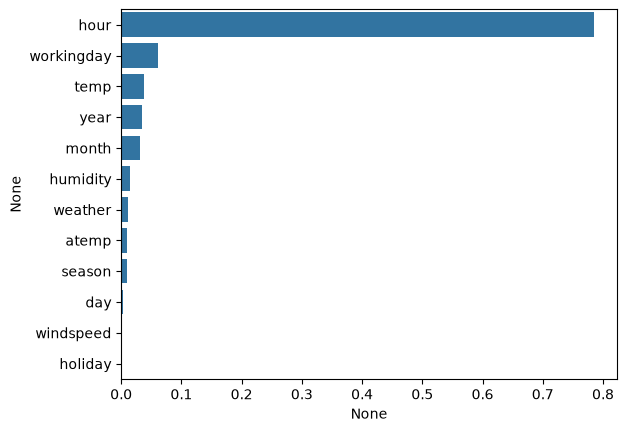

In [14]:
import seaborn as sns
gb_reg = GradientBoostingRegressor(random_state = 42,
                                   n_estimators = 1000)

gb_reg.fit(X_data, y_target_log)

feature_series = pd.Series(data = gb_reg.feature_importances_,
                           index = X_data.columns)
feature_series = feature_series.sort_values(ascending=False)
sns.barplot(x=feature_series, y=feature_series.index)

In [15]:
test_df = bike_test.copy()

test_df['datetime'] = pd.to_datetime(test_df['datetime'])
test_df['year'] = test_df.datetime.apply(lambda x: x.year)
test_df['month'] = test_df.datetime.apply(lambda x: x.month)
test_df['day'] = test_df.datetime.apply(lambda x: x.day)
test_df['hour'] = test_df.datetime.apply(lambda x: x.hour)
test_df = test_df.drop('datetime', axis = 1)

In [24]:
pred_log = gb_reg.predict(test_df)
pred = np.round(np.expm1(pred_log)).astype(int)
pred

array([  9,   4,   2, ..., 166, 130,  81], shape=(6493,))

In [25]:
result_df = pd.DataFrame({
    'datetime' : bike_test['datetime'],
    'count' : pred
})

result_df.head()

,datetime,count
0,2011-01-20 00:00:00,9
1,2011-01-20 01:00:00,4
2,2011-01-20 02:00:00,2
3,2011-01-20 03:00:00,1
4,2011-01-20 04:00:00,1
